<a href="https://colab.research.google.com/github/Arunya-123/Machine-learning-Repo/blob/main/House_price_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**House Price Prediction**

House prices depend on factors like **area, location, number of bedrooms, and facilities**. In this project, the goal is to build a machine learning model that predicts the price of a house based on these features. This helps understand how data and machine learning can be used to estimate property price.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data= fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [ ]:
df=pd.DataFrame(data.data,columns=data.feature_names)
df["House price"]= data.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,House price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
df.shape

(20640, 9)

In [ ]:
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
House price,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   House price  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,House price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: >

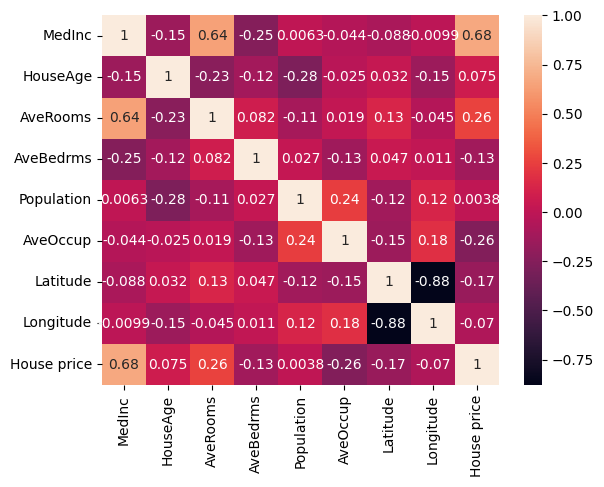

In [ ]:
sns.heatmap(df.corr(method= 'spearman'),annot=True)


<Axes: xlabel='MedInc', ylabel='House price'>

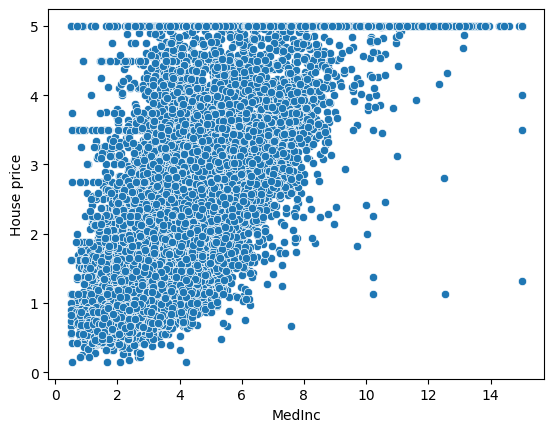

In [ ]:
sns.scatterplot(x="MedInc",y="House price",data=df)

<Axes: >

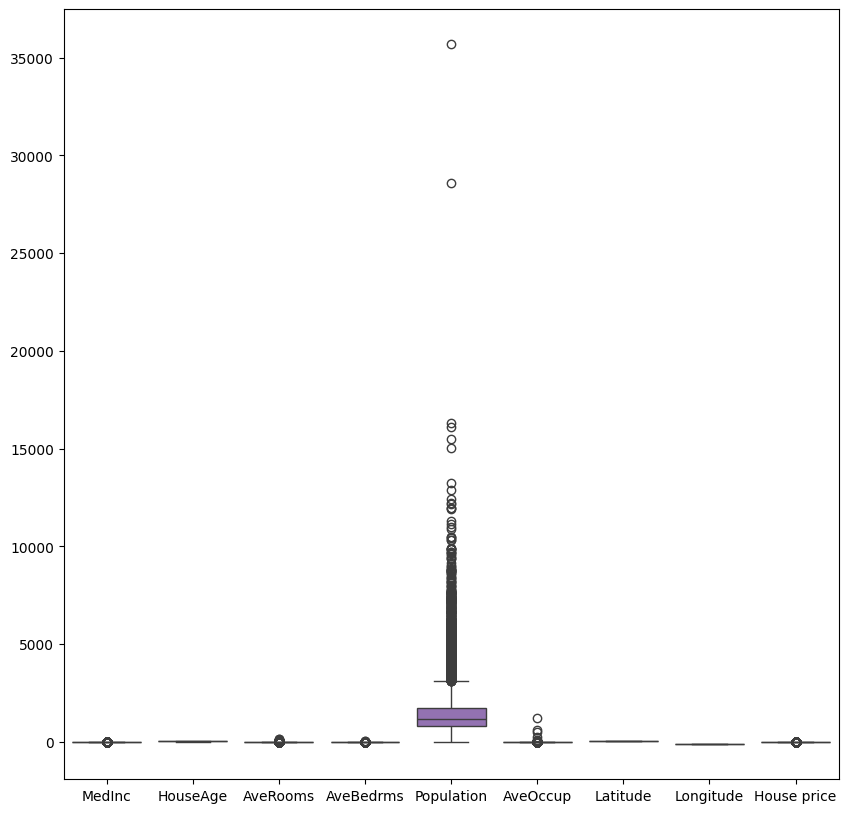

In [ ]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df)

In [ ]:
X=df.drop("House price",axis=1)
y=df["House price"]

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 3. Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# 4. Model Training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:

# 5. Prediction
y_pred = model.predict(X_test_scaled)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

In [ ]:
# 6. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:

print("\nModel Evaluation")
print("-----------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)



Model Evaluation
-----------------
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451


In [ ]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
tree_pred = tree_model.predict(X_test)
tree_pred

array([0.414  , 1.203  , 5.00001, ..., 5.00001, 0.66   , 2.172  ])

In [ ]:
print("Decision Tree Results")
print("MSE:", mean_squared_error(y_test, tree_pred))
print("R2 Score:", r2_score(y_test, tree_pred))

Decision Tree Results
MSE: 0.495235205629094
R2 Score: 0.622075845135081


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)


In [ ]:
print("Random Forest Results")
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MSE: 0.2553684927247781
R2 Score: 0.8051230593157366


In [ ]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

In [ ]:
print("KNN Results")
print("MSE:", mean_squared_error(y_test, knn_pred))
print("R2 Score:", r2_score(y_test, knn_pred))

KNN Results
MSE: 0.4324216146043236
R2 Score: 0.6700101862970989


In [ ]:
models=["linear regression","DecisionRegressor","RandomFOrestRegressor","KNeighborsRegressior"]
accuracy=[0.57,0.62,0.80,0.43]
pd. DataFrame({"models":models,"Accuracy":accuracy})

,models,Accuracy
0,linear regression,0.57
1,DecisionRegressor,0.62
2,RandomFOrestRegressor,0.80
3,KNeighborsRegressior,0.43


From the above model prediction RandomForestRegressor give r square value 0.80, meaning this model can be able to understand 80 percentage pattern of the unseen datapoints.

This model also suffering from outliers and multicolinearity.
linearRegressor and kNN are sensitive to this proparty of datapoints.

Here MedInc feature has only high correlation with target variable House_price
